# PIN detector

In [14]:
# Thorlabs PDA05CF2
from numpy import log10
from scipy.constants import Planck as h
from scipy.constants import speed_of_light as c
trans_gain = 5e3
nep = 1.26e-11
responsivity = 1.04

electrical_noise_dBm = -74
dark_noise_dBm = -80
rbw = 1e6
v_dc = .777+.002
resistance = 50
center_wavelength = 1565e-9 

rin_dBc = electrical_noise_dBm  + 10 * log10 (resistance/(1000 * v_dc**2 * rbw))
power_in = v_dc / trans_gain / responsivity
rin_shot= 2 * h * c / center_wavelength / power_in 
rin_shot_dBc = 10 * log10( rin_shot)
rin_detector_dBc = dark_noise_dBm + 10 * log10 (resistance/(1000 * v_dc**2 * rbw))
rin_excess_dBc = 10*log10(10**(rin_dBc/10) - rin_shot - 10**(rin_detector_dBc/10))
print(f'Total RIN = {rin_dBc:.0f} dBc/Hz')
print(f'RIN from shot noise: {rin_shot_dBc:.0f} dBc/Hz')
print(f'RIN from detector noise: {rin_detector_dBc:.0f} dBc/Hz')
print(f'Excess RIN = {rin_excess_dBc:.0f} dBc/Hz')

Total RIN = -145 dBc/Hz
RIN from shot noise: -148 dBc/Hz
RIN from detector noise: -151 dBc/Hz
Excess RIN = -151 dBc/Hz


In [19]:
from numpy import log10
from scipy.constants import Planck as h
from scipy.constants import speed_of_light as c
electrical_noise_dBm = -75
rbw = 1e5
v_dc = .45
resistance = 50
trans_gain = 40e3
responsivity = .3
center_wavelength = 700e-9 

rin_dBc = electrical_noise_dBm  + 10 * log10 (resistance/(1000 * v_dc**2 * rbw))
power_in = v_dc / trans_gain / responsivity
rin_shot= 2 * h * c / center_wavelength / power_in 
rin_shot_dBc = 10 * log10( rin_shot)
print(f'RIN = {rin_dBc:.0f} dBc/Hz')
print(f'RIN from shot noise: {rin_shot_dBc:.0f} dBc/Hz')

RIN = -131 dBc/Hz
RIN from shot noise: -138 dBc/Hz


# Avalanche detector

In [ ]:
from numpy import log10
from scipy.constants import Planck as h
from scipy.constants import speed_of_light as c
electrical_noise_dBm = -67.5
rbw = 1e3
v_dc = 1.8
resistance = 50
trans_gain = 50e3
photon_multiplier = 50
ion_ratio = .05 # guess
responsivity = 12 # Responsivity @ target wavelength (A/W)
center_wavelength = 400e-9 
excess_noise = ion_ratio * photon_multiplier + (1-ion_ratio) * (2- 1/photon_multiplier)

rin_dBc = electrical_noise_dBm  + 10 * log10 (resistance/(1000 * v_dc**2 * rbw))
power_in = v_dc / trans_gain / responsivity
rin_shot= 2 * h * c * excess_noise**.5 / center_wavelength / power_in 
rin_shot_dBc = 10 * log10( rin_shot)
print(f'RIN = {rin_dBc:.0f} dBc/Hz')
print(f'RIN from shot noise: {rin_shot_dBc:.0f} dBc/Hz')

RIN = -116 dBc/Hz
RIN from shot noise: -120 dBc/Hz


In [7]:
print(10 * log10(1.02e-8/50 * 1000))

-66.903698325741


# RIN Plot

### RFSA

    Frequency    Power
0       69535   -95.18
1      139070   -98.12
2      208606  -200.00
3      278141  -200.00
4      347676   -98.46
..        ...      ...
745  51873254   -80.90
746  51942789   -84.31
747  52012324   -55.80
748  52081859   -82.52
749  52151394   -80.20

[750 rows x 2 columns]


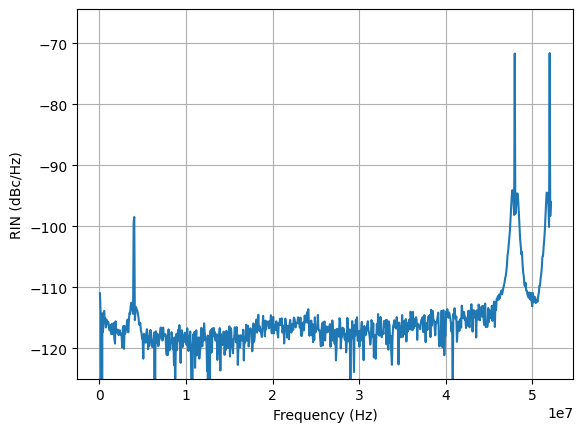

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from numpy import log10
from scipy.constants import Planck as h
from scipy.constants import speed_of_light as c
file_in = pd.read_csv(r"Z:\Research Projects\UVDCS\Data\4-20-2026\rin_trace.csv", skiprows=1544, index_col=False, header=0, names=['Frequency', 'Power'])
file_in = file_in[:-2]

print(file_in)

electrical_noise_dBm = pd.to_numeric(file_in['Power']).to_numpy()
frequencies_hz = pd.to_numeric(file_in['Frequency']).to_numpy()

rbw = 10e3
v_dc = 13.8e-3
resistance = 50
trans_gain = 5e3
photon_multiplier = 1
ion_ratio = .05 # guess
responsivity = .27 # Responsivity @ target wavelength (A/W)
center_wavelength = 550e-9 
# excess_noise = ion_ratio * photon_multiplier + (1-ion_ratio) * (2- 1/photon_multiplier)
excess_noise = 1

rin_dBc = 10 * log10 (resistance/(1000 * v_dc**2 * rbw))+electrical_noise_dBm  
power_in = v_dc / trans_gain / responsivity
rin_shot= 2 * h * c * excess_noise**.5 / center_wavelength / power_in 
rin_shot_dBc = 10 * log10( rin_shot)
# print(f'RIN = {rin_dBc:.0f} dBc/Hz')
# print(f'RIN from shot noise: {rin_shot_dBc:.0f} dBc/Hz')
plt.plot(frequencies_hz, rin_dBc)
plt.xlabel('Frequency (Hz)')
plt.ylabel('RIN (dBc/Hz)')
plt.ylim(-125,)
plt.grid()

### VSA

c:\Users\Splinter-User\miniconda3\envs\dev-table\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


41.56769596199525
1.2028571428571428e-06
5.269791348081639e-12


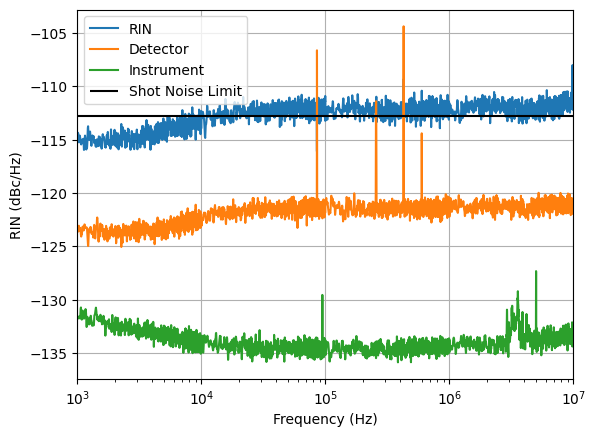

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from numpy import log10, loadtxt
from scipy.constants import elementary_charge as q
directory = Path(r"Z:\Research Projects\UVDCS\Data\6-22-2026\Blue RIN\175mV")
light_file = directory / 'LightNoise.txt'
detector_file = directory / 'DetectorNoiseFloor.txt'
instrument_file = directory / 'InstrumentNoiseFloor.txt'
v_dc = 130e-3
trans_gain_hiz = 10e3
trans_gain_50 = 5e3
photon_multiplier = 10 *175/42.1 # guess for variable gain
ion_ratio = .08 # guess
responsivity = photon_multiplier/100 * 26 # Responsivity @ target wavelength (A/W)
# center_wavelength = 420e-9 

light_data = loadtxt(light_file)
detector_data = loadtxt(detector_file)
instrument_data = loadtxt(instrument_file)

data = pd.DataFrame({'Frequency (Hz)': light_data[:,0],
                     'Light Noise (V/rt Hz)': light_data[:,1],
                     'Detector Noise (V/rt Hz)': detector_data[:,1],
                     'Instrument Noise (V/rt Hz)': instrument_data[:,1]
                     })

# background_subtracted = data['Light Noise (V/rt Hz)']
background_subtracted = data['Light Noise (V/rt Hz)']**2 - data['Detector Noise (V/rt Hz)']**2 
normalized = background_subtracted/v_dc**2 *(trans_gain_hiz**2/trans_gain_50**2)
data['RIN (dBc/Hz)'] = 10 * log10(normalized)
# data['RIN (dBc/Hz)'] = 10 * log10(data['Light Noise (V/rt Hz)']**2/v_dc**2)
data['Detector Noise (dBc/Hz)'] = 10 * log10(data['Detector Noise (V/rt Hz)']**2/ v_dc**2*(trans_gain_hiz**2/trans_gain_50**2))
data['Instrument Noise (dBc/Hz)'] = 10*log10(data['Instrument Noise (V/rt Hz)']**2 / v_dc**2*(trans_gain_hiz**2/trans_gain_50**2))

excess_noise = ion_ratio * photon_multiplier + (1-ion_ratio) * (2- 1/photon_multiplier)
# excess_noise = 2

power_in = v_dc / trans_gain_hiz / responsivity
# power_in = 5e-6
print(photon_multiplier)
print(power_in)
rin_shot= 2 * q * photon_multiplier * excess_noise / responsivity / power_in 

print(rin_shot)

rin_shot_dBc = 10 * log10( rin_shot)
# print(f'RIN = {rin_dBc:.0f} dBc/Hz')
# print(f'RIN from shot noise: {rin_shot_dBc:.0f} dBc/Hz')
plt.semilogx(data['Frequency (Hz)'], data['RIN (dBc/Hz)'], label='RIN')
plt.semilogx(data['Frequency (Hz)'], data['Detector Noise (dBc/Hz)'], label='Detector')
plt.semilogx(data['Frequency (Hz)'], data['Instrument Noise (dBc/Hz)'], label='Instrument')
plt.hlines(rin_shot_dBc, min(data['Frequency (Hz)']), max(data['Frequency (Hz)']), color='k',label='Shot Noise Limit')


plt.xlabel('Frequency (Hz)')
plt.ylabel('RIN (dBc/Hz)')
# plt.ylim(-130, -120,)
# plt.xlim(1e5,5e7)
plt.xlim(min(data['Frequency (Hz)']),max(data['Frequency (Hz)']))
plt.legend()
plt.grid()
